***This file shows heatmaps of eye data and other graphs and graphics***

*Data is gathered from the folder "../logs/"*

In [22]:
import os
import glob
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp

*Heatmap of fixation locations*
* One heatmap for each section, aggregated across participants

Found 16 eye_events.csv files
Read 101,393 rows total
Plotting event type: fixation
Min points per heatmap: 100
Categories with heatmaps: 12


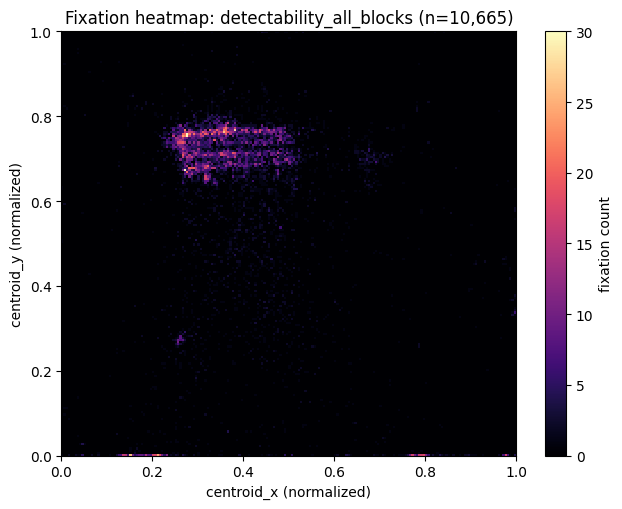

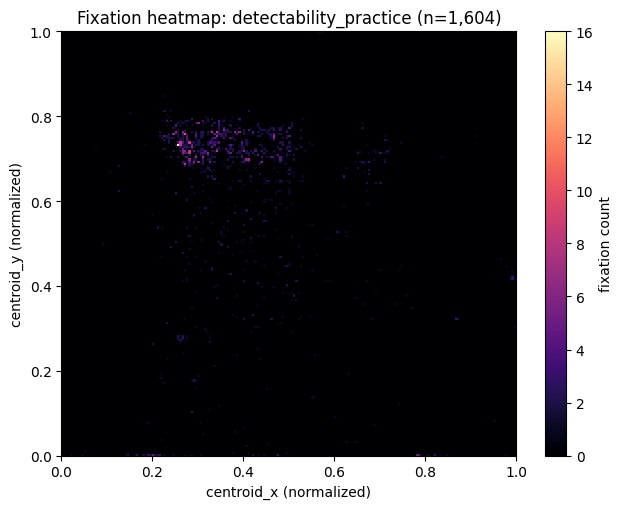

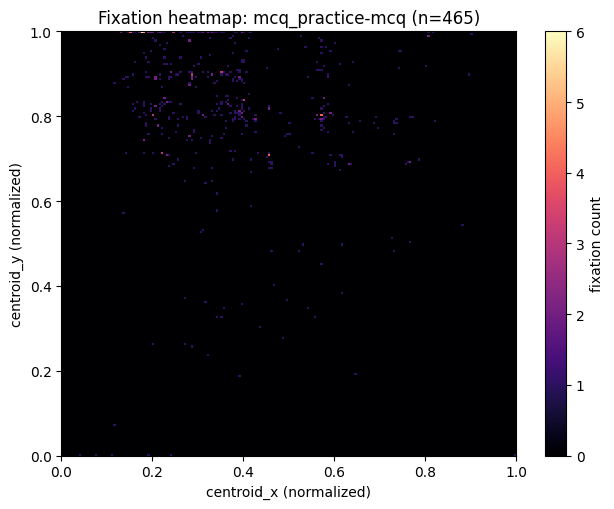

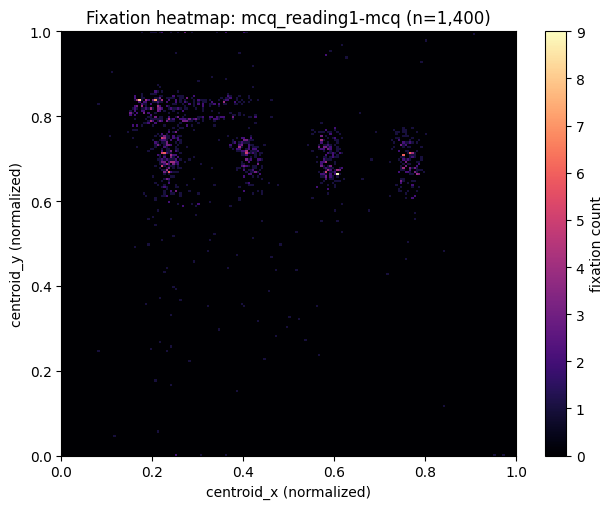

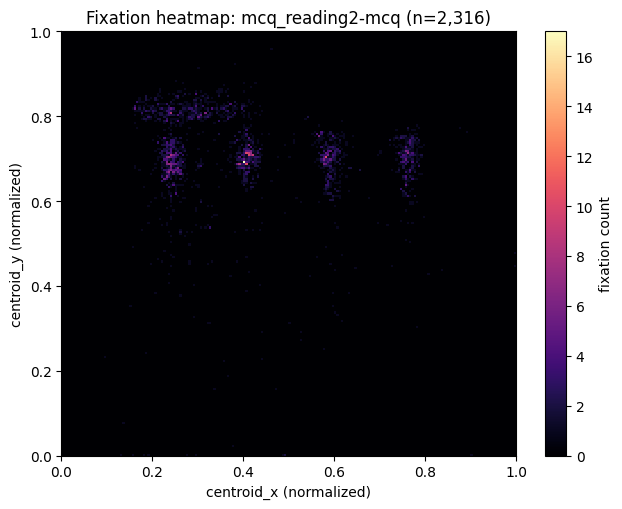

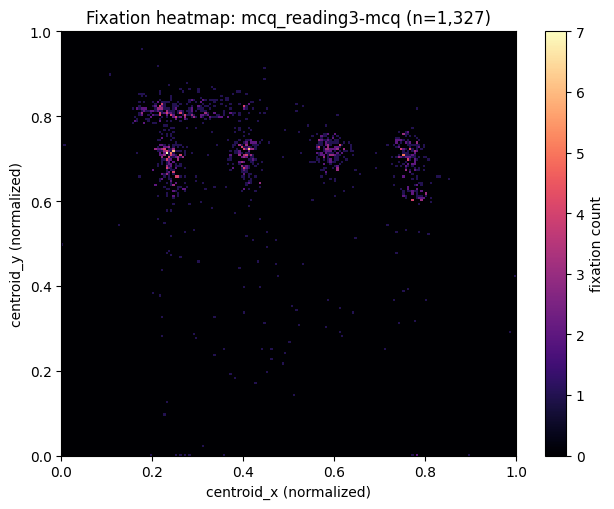

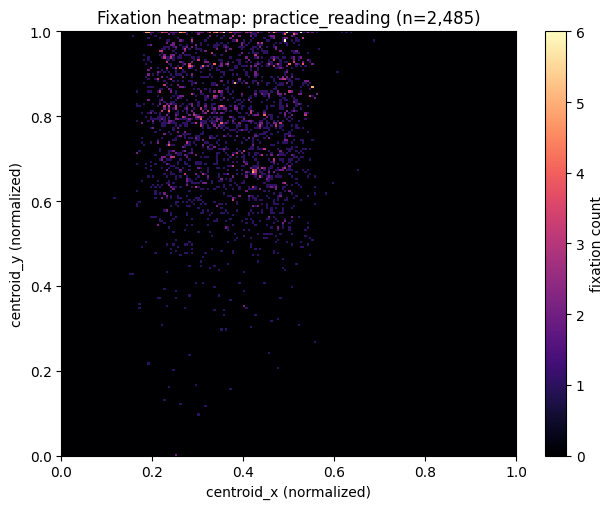

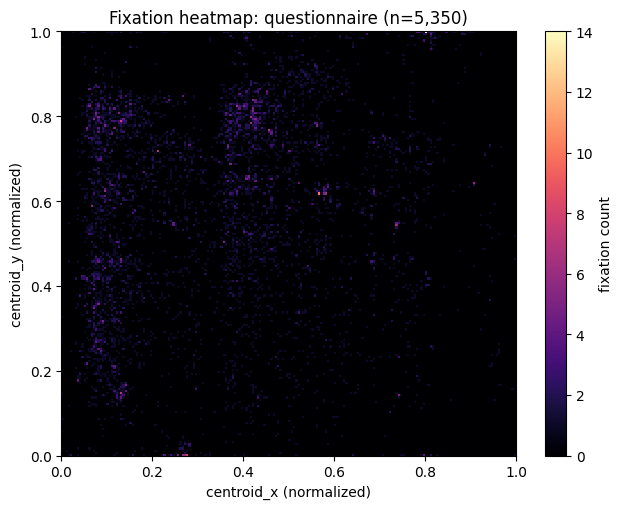

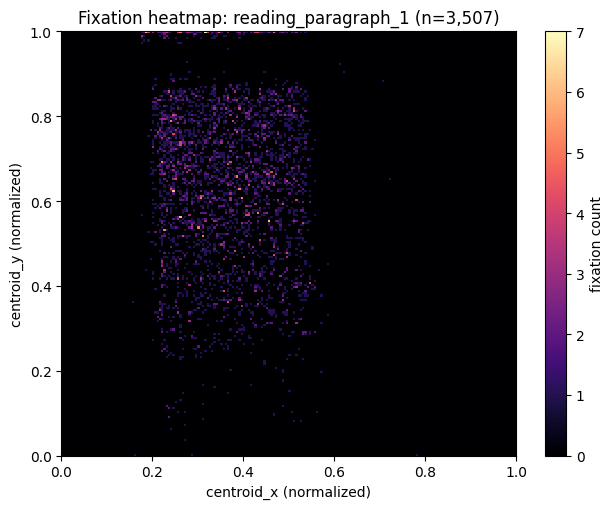

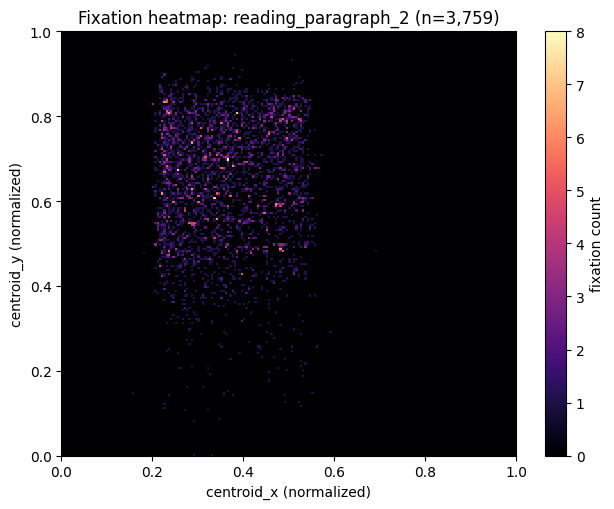

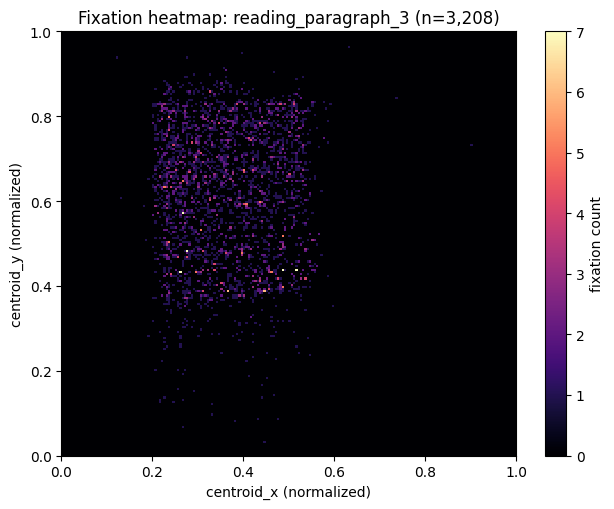

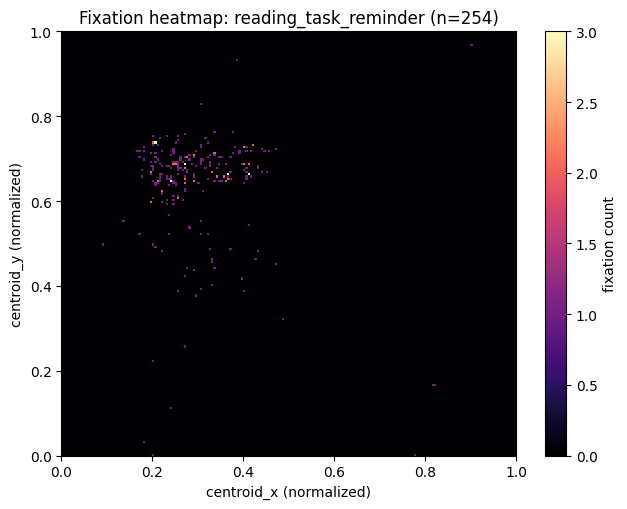

In [23]:
from collections import defaultdict

# expected output from ParticipantTest.py _write_eye_events_csv()
# Centroids are raw NDC coordinates from Tobii: (0,0) at top-left, x increases right, y increases down
required_cols = {
    "section",
    "phase",
    "window_label",
    "event_type",
    "centroid_x",
    "centroid_y",
}
files = glob.glob(os.path.join("..", "logs", "**", "eye_events.csv"), recursive=True)

if not files:
    raise FileNotFoundError(
        "No eye_events.csv files found under ../logs/. Run ParticipantTest sessions first."
    )

MIN_POINTS_PER_HEATMAP = 100  # avoid noisy one-off trial figures

def _normalize_label(val):
    if val is None:
        return ""
    s = str(val).strip()
    if not s or s.lower() in {"nan", "none"}:
        return ""
    return s

def _infer_category(section, phase, window_label):
    section = _normalize_label(section).lower()
    phase = _normalize_label(phase).lower()
    label = _normalize_label(window_label).lower()

    # Strong section-level grouping for ParticipantTest naming patterns.
    if re.search(r"reading_paragraph_\d+", label):
        return re.search(r"reading_paragraph_\d+", label).group(0)
    if re.search(r"mcq_reading\d+-mcq", label):
        return re.search(r"mcq_reading\d+-mcq", label).group(0)
    if label == "mcq_practice-mcq":
        return "mcq_practice-mcq"
    if "practice_reading" in label:
        return "practice_reading"

    if "detectability_practice" in label or phase == "practice":
        return "detectability_practice"
    if re.search(r"eye_all_blocks_\d+_trial_\d+", label) or phase == "all_blocks":
        return "detectability_all_blocks"

    if "reading_task_reminder" in label:
        return "reading_task_reminder"
    if "questionnaire" in label or "questionnaire" in section:
        return "questionnaire"

    # Fall back to structured metadata before raw label.
    if section and phase:
        return f"{section}::{phase}"
    if section:
        return section
    if phase:
        return phase
    if label:
        return label
    return "unknown_window"

# First pass: gather all rows and determine which event type has usable centroids
all_rows = []
valid_counts = defaultdict(int)
total_rows = 0

for file_path in files:
    try:
        df = pd.read_csv(
            file_path,
            usecols=lambda c: c in required_cols,
            low_memory=False,
        )
    except Exception as exc:
        print(f"Skipping unreadable file: {file_path} ({exc})")
        continue

    if not {"event_type", "centroid_x", "centroid_y"}.issubset(df.columns):
        print(f"Skipping file with missing core columns: {file_path}")
        continue

    total_rows += len(df)
    df["event_type"] = df["event_type"].astype(str).str.lower().str.strip()
    df["centroid_x"] = pd.to_numeric(df["centroid_x"], errors="coerce")
    df["centroid_y"] = pd.to_numeric(df["centroid_y"], errors="coerce")
    df = df[np.isfinite(df["centroid_x"]) & np.isfinite(df["centroid_y"])]
    df = df[df["centroid_x"].between(0.0, 1.0) & df["centroid_y"].between(0.0, 1.0)]
    if df.empty:
        continue

    for etype, cnt in df["event_type"].value_counts().items():
        valid_counts[etype] += int(cnt)

    all_rows.append(df)

if not all_rows:
    raise RuntimeError(
        "No valid centroid coordinates found in eye_events.csv files."
    )

combined = pd.concat(all_rows, ignore_index=True)

# Prefer saccades, but automatically fall back to fixations if needed
if valid_counts.get("saccade", 0) > 0:
    event_type_to_plot = "saccade"
elif valid_counts.get("fixation", 0) > 0:
    event_type_to_plot = "fixation"
else:
    event_type_to_plot = max(valid_counts, key=valid_counts.get)

plot_df = combined[combined["event_type"].eq(event_type_to_plot)].copy()
if plot_df.empty:
    raise RuntimeError(
        f"No rows available for event_type='{event_type_to_plot}' after filtering."
    )

plot_df["category"] = [
    _infer_category(s, p, w)
    for s, p, w in zip(plot_df["section"], plot_df["phase"], plot_df["window_label"])
]

# Keep only categories with enough points to be interpretable.
counts = plot_df["category"].value_counts()
keep_categories = counts[counts >= MIN_POINTS_PER_HEATMAP].index.tolist()
plot_df = plot_df[plot_df["category"].isin(keep_categories)]

data_by_category = defaultdict(list)
for cat, grp in plot_df.groupby("category", dropna=False):
    category_name = _normalize_label(cat) or "unknown_window"
    data_by_category[category_name].append(
        grp[["centroid_x", "centroid_y"]].to_numpy(dtype=np.float32)
    )

for category_name in list(data_by_category.keys()):
    data_by_category[category_name] = np.vstack(data_by_category[category_name])

print(f"Found {len(files)} eye_events.csv files")
print(f"Read {total_rows:,} rows total")
print(f"Plotting event type: {event_type_to_plot}")
print(f"Min points per heatmap: {MIN_POINTS_PER_HEATMAP}")
print(f"Categories with heatmaps: {len(data_by_category)}")

bins = 200 #high detail, fast for large run

for category_name in sorted(data_by_category.keys()):
    pts = data_by_category[category_name]
    if pts.size == 0:
        continue

    x = pts[:, 0]
    y = pts[:, 1]

    H, xedges, yedges = np.histogram2d(
        y,
        x,
        bins=bins,
        range=[[0.0, 1.0], [0.0, 1.0]],
    )

    plt.figure(figsize=(6.5, 5.2))
    plt.imshow(
        H,
        origin="upper",
        extent=[0.0, 1.0, 0.0, 1.0],
        cmap="magma",
        aspect="auto",
        interpolation="nearest",
    )
    plt.colorbar(label=f"{event_type_to_plot} count")
    plt.title(f"{event_type_to_plot.capitalize()} heatmap: {category_name} (n={len(pts):,})")
    plt.xlabel("centroid_x (normalized)")
    plt.ylabel("centroid_y (normalized)")
    plt.tight_layout()
    plt.show()
